In [113]:
import numpy as np
import matplotlib.pyplot as plt

Problem 1

Pokaż, że suma dwóch (lub ogólniej – większej liczby) zmiennych normalnych
nie musi mieć rozkładu normalnego.

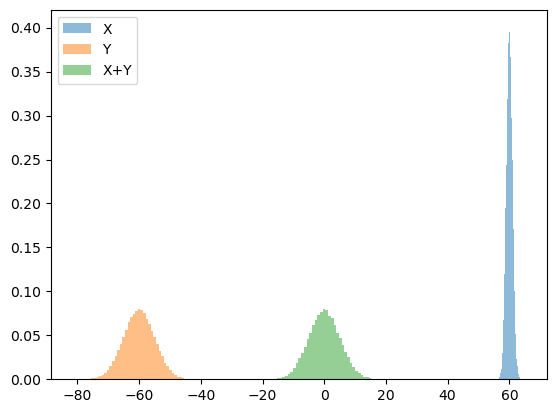

In [114]:
X = np.random.normal(loc=60, scale=1, size=100000)
Y = np.random.normal(loc=-60, scale=5, size=100000) 
XandY = X + Y

plt.hist(X, bins=50, density=True, alpha=0.5, label='X')
plt.hist(Y, bins=50, density=True, alpha=0.5, label='Y')
plt.hist(XandY, bins=50, density=True, alpha=0.5, label='X+Y')
plt.legend()
plt.show()

Problem 2

(Symulacja rozkładu α-stabilnego). Przygotuj program, który symuluje próbkę
o symetrycznym rozkładzie α-stabilnym S(α, β, γ, δ; 0) oraz S(α, β, γ, δ; 1) zdefiniowanych w
definicjach Def. 1.7 oraz Def. 1.8 w Rozdziale 1.

In [115]:
# The alpha stable distribution 
def genZ(alpha, beta, theta=np.random.uniform(-np.pi/2, np.pi/2), W=np.random.exponential(1)):
  if alpha == 1: 
    Z = (2/np.pi) * (((np.pi/2)+beta*theta)*np.tan(theta) - beta*np.log((np.pi/2)*W*np.cos(theta)/((np.pi/2)+beta*theta)))
  else:
    theta0 = np.arctan(beta*np.tan(np.pi*alpha/2))/alpha
    Z = (np.sin(alpha*(theta0 + theta))/((np.cos(alpha*theta0)*np.cos(theta))**(1/alpha))) * ((np.cos(alpha*theta0 + (alpha - 1)*theta)/W)**((1-alpha)/alpha))
  return Z

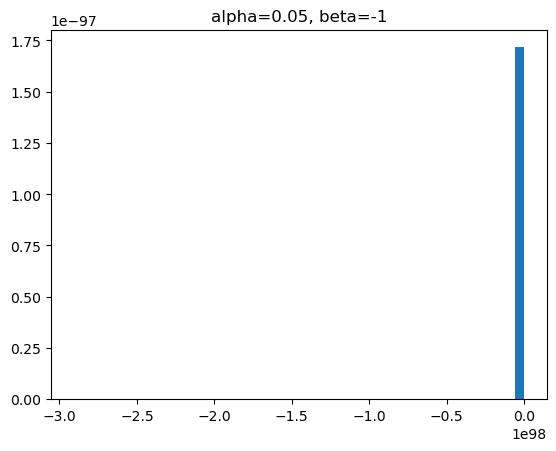

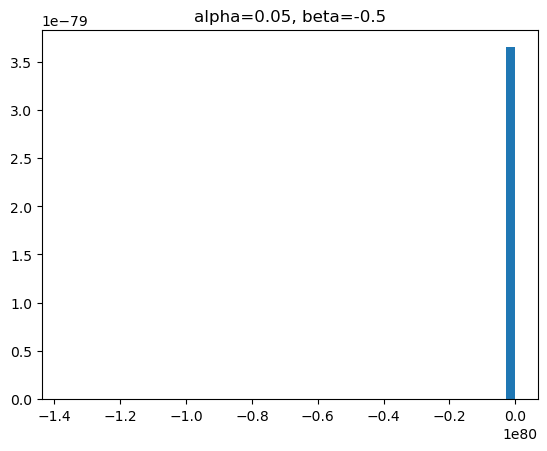

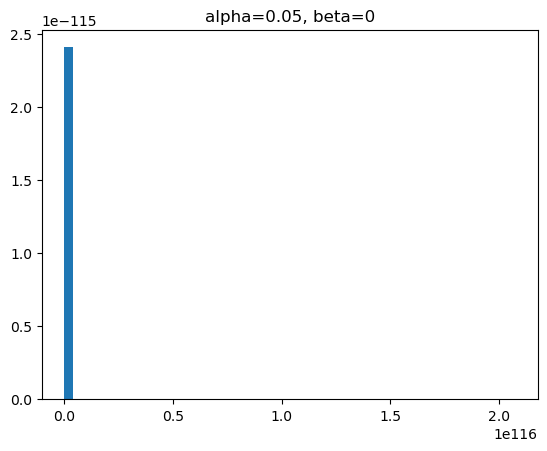

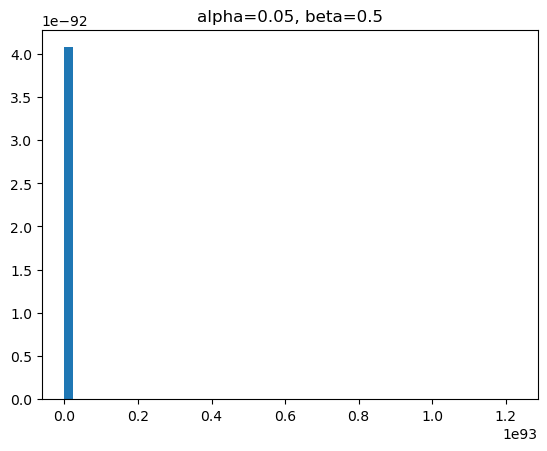

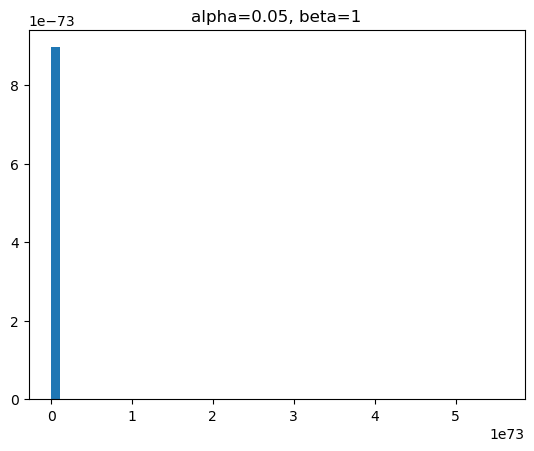

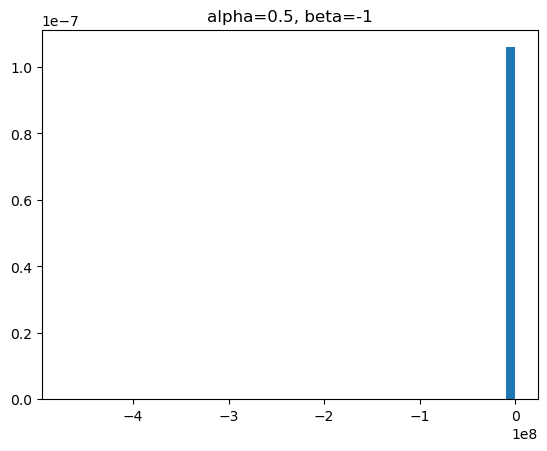

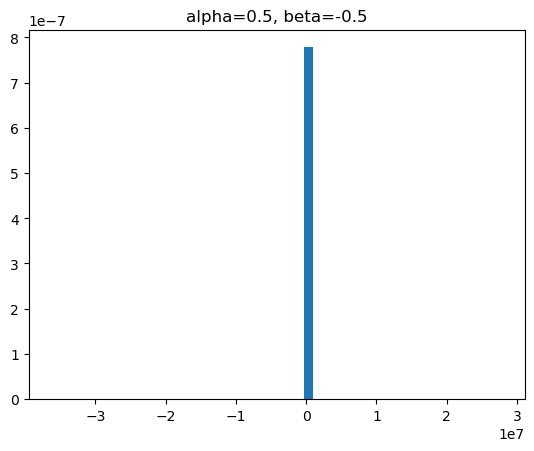

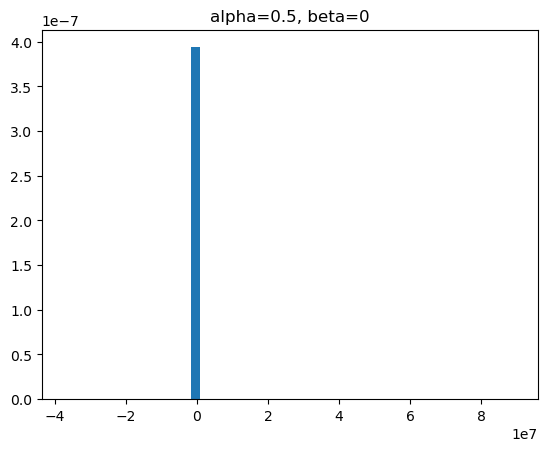

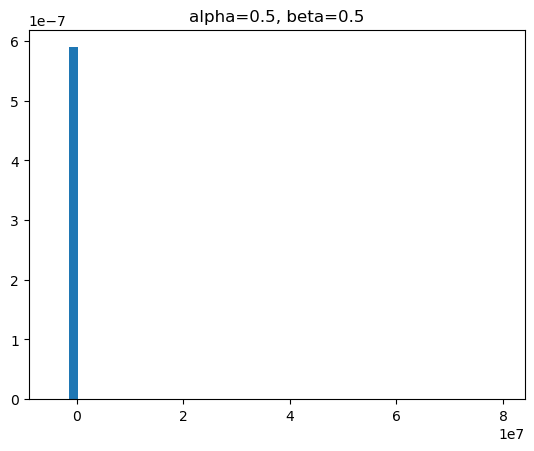

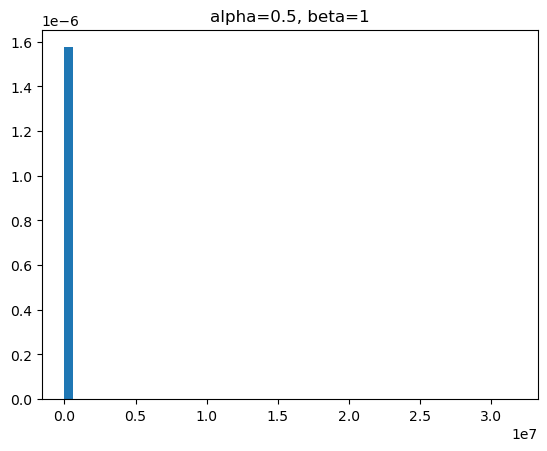

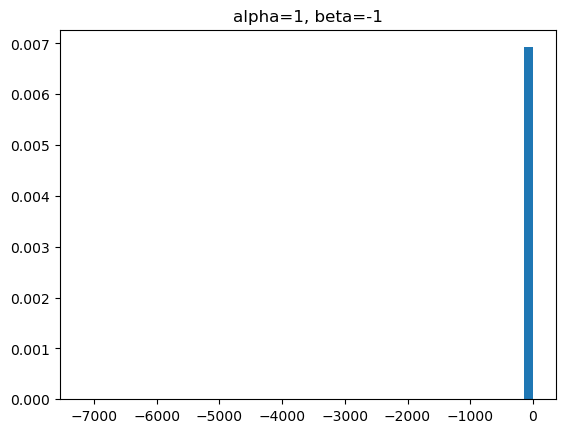

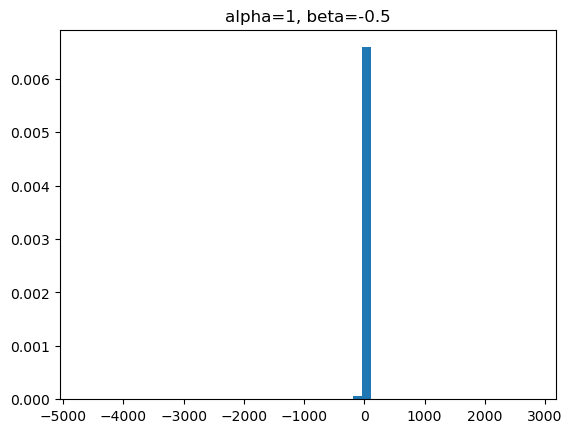

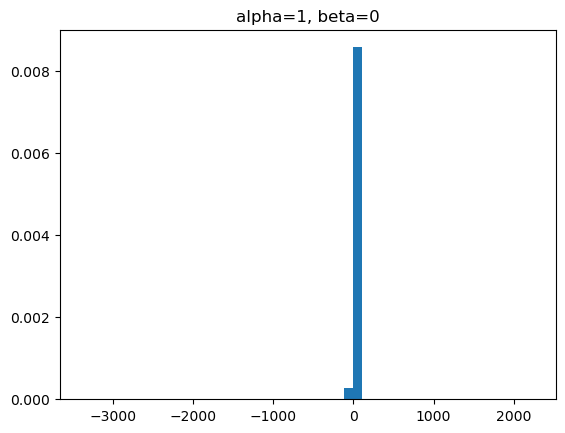

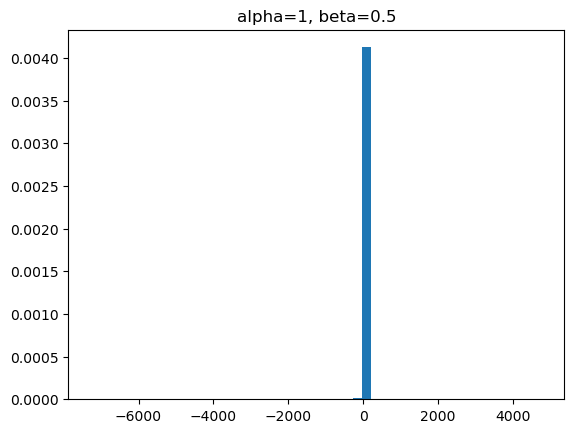

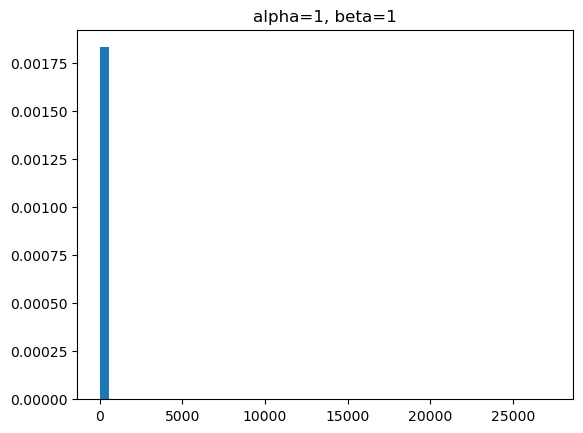

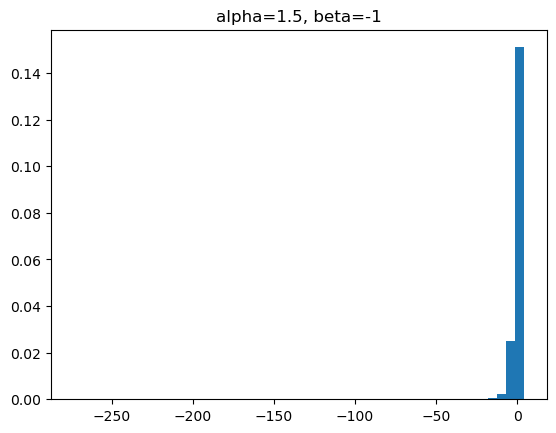

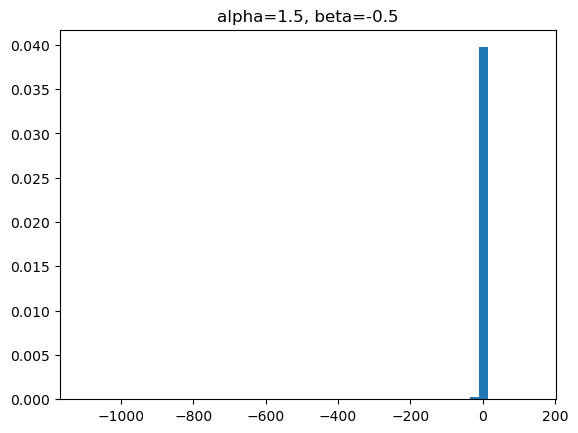

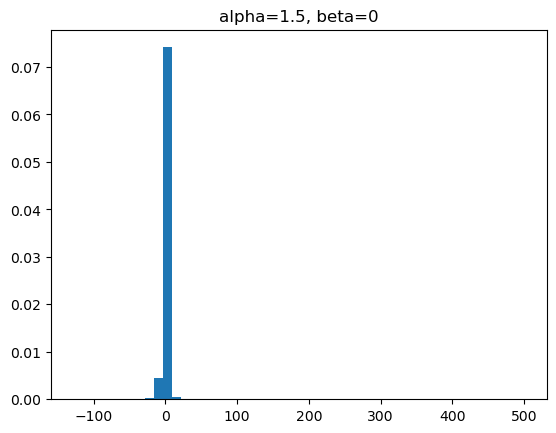

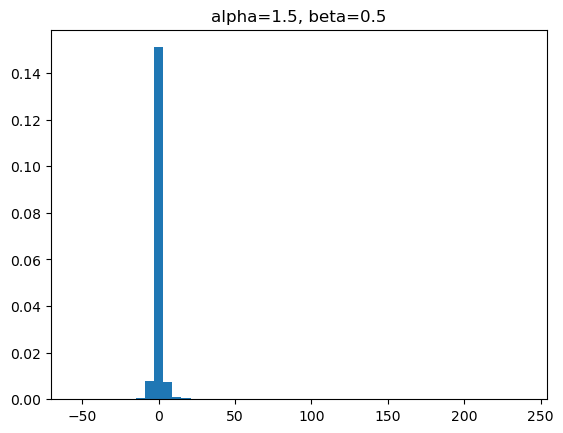

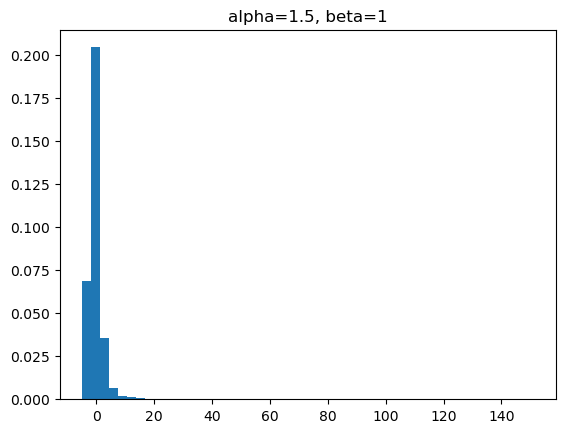

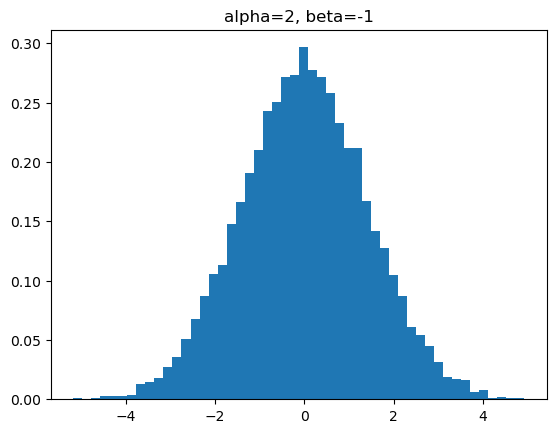

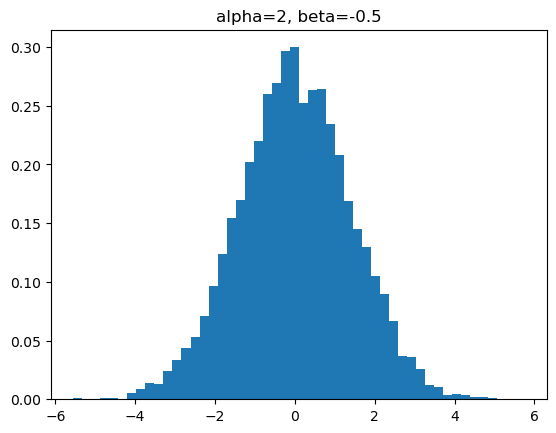

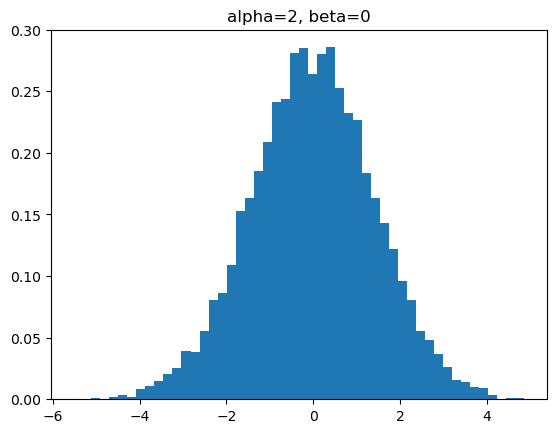

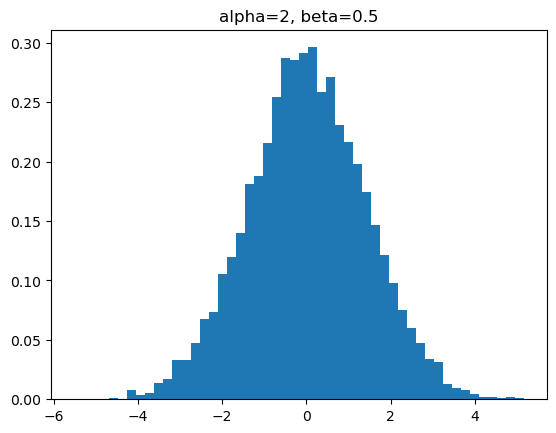

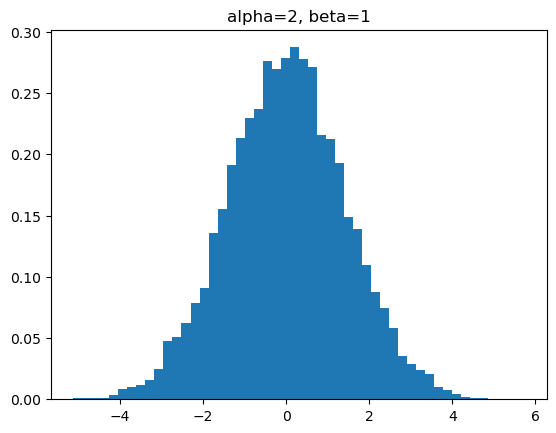

In [116]:
Ztable = []
alphaBetaZ = []

for alpha in [0.05, 0.5, 1, 1.5, 2]:
  for beta in [-1, -0.5, 0, 0.5, 1]:
    for i in range(10000):
      theta = np.random.uniform(-np.pi/2, np.pi/2)
      W = np.random.exponential(1)
      Z = genZ(alpha, beta, theta, W)
      Ztable.append(Z)
    alphaBetaZ.append((alpha, beta, Ztable))
    Ztable = []
  
for alpha, beta, Z in alphaBetaZ:
  plt.hist(Z, bins=50, density=True)
  plt.title(f'alpha={alpha}, beta={beta}')
  plt.show()

In [117]:
def S(alpha, beta, gamma, delta, zeroOne, Z):
  if zeroOne == 0:
    if alpha == 1:
      X = gamma*Z + delta
    else:
      X = gamma*(Z-beta*np.tan(np.pi/2*(alpha))) +delta
  else:
    if alpha == 1:
      X = gamma*Z + (delta + beta*(2/np.pi)*gamma*np.log(gamma))
    else:
      X = gamma*Z + delta
  return X

Problem 3

(Funkcja charakterystyczna symetrycznych rozkładów α-stabilnych). Porów-
naj empiryczną funkcję charakterystyczną obliczoną dla próbek z symetrycznego rozkładu α-
stabilnego (β = 0, δ = 0) z jej dokładną postacią
α
φX (t) = e−c|t| ,
t∈R
dla pewnego c ≥ 0 (jak parametr c jest powiązany z pozostałymi parametrami rozkładu α-
stabilnego?).
Jak można w prosty sposób wyjaśnić, że dla symetrycznego rozkładu α-stabilnego funkcja
charakterystyczna nie posiada części urojonej?

Ss mean: 16371.16248955707
Zz mean: 16371.16248955707


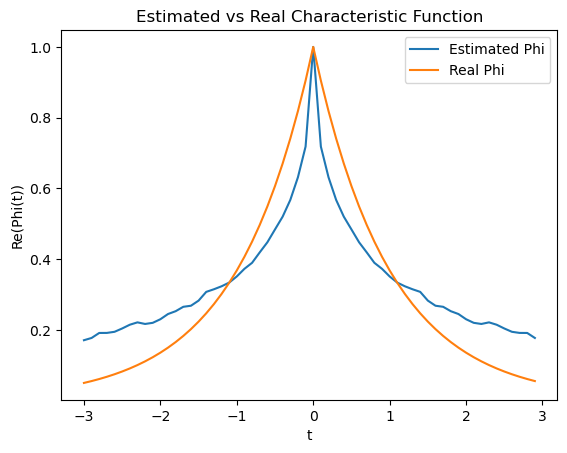

In [118]:
def estPhi(t,X):
  N = len(X)
  phi = 0
  for x in X:
    phi += np.exp(1j*t*x) 
  return phi/N

def realPhi(t,c,alpha):
  return np.exp(-c*np.abs(t)**alpha)
 

alpha = 0.5
beta = 0.0
gamma = 1
delta = 0
Ss = np.array([])
Zz = np.array([])

for i in range(10000):

  theta = np.random.uniform(-np.pi/2, np.pi/2)
  W = np.random.exponential(1)
  Z = genZ(alpha, beta, theta, W)
  S_value = S(alpha, beta, gamma, delta, 1, Z)
  Ss = np.append(Ss, S_value)
  Zz = np.append(Zz, Z)

print("Ss mean:", np.mean(Ss))
print("Zz mean:", np.mean(Zz))

phis = []
for t in np.arange(-3.0, 3.0, 0.1):
  ePhi = estPhi(t, Ss)
  rPhi = realPhi(t, 1, 1)
  phis.append((t, ePhi, rPhi))


#Y axis - real phi, X axis - estimated phi
plt.plot([t for t, ePhi, rPhi in phis], [np.real(ePhi) for t, ePhi, rPhi in phis], label='Estimated Phi')
plt.plot([t for t, ePhi, rPhi in phis], [np.real(rPhi) for t, ePhi, rPhi in phis], label='Real Phi')
plt.title('Estimated vs Real Characteristic Function')
plt.xlabel('t')
plt.ylabel('Re(Phi(t))')
plt.legend()
plt.show()

#za 2 tyg kart. opisz znaczenie param w rozkladnie alpha stabilnym, beta, gamma, delta, zeroOne

Problem 4

(Porównanie gęstości dla znanych przypadków). Dla przypadków:
1. rozkład normalny,
2. rozkład Cauchy’ego,
3. rozkład Lévy’ego,
znajdź odpowiednie parametry rozkładu α-stabilnego. Następnie porównaj estymowane gęsto-
ści (oraz, jeśli to możliwe, dystrybuanty) z ich analitycznymi odpowiednikami przedstawio-
nymi w uwagach 1 − 3.

Problem 5

(Ogon dystrybuanty i gęstości). Korzystając z symulacji Monte Carlo pokaż,
że dla X ∼ S(α, β, γ, δ; 0) z 0 < α < 2, −1 < β ≤ 1 zachodzi następujące zachowanie dla
t → ∞:
• P(X > x) ∼ γ α cα (1 + β)t−α ,
• fX (t) ∼ αγ α cα (1 + β)t−(α+1) ,
oraz dla −1 ≤ β < 1, gdy −t → −∞:
• P(X < −t) ∼ γ α cα (1 − β)t−α ,
• fX (−t) ∼ αγ α cα (1 − β)t−(α+1) .
W obu przypadkach parametr
 απ  Γ(α)
.
cα = sin
2
π

# LISTA 2

In [119]:
import scipy.stats as stats
import math

Problem 1:
P(X > t) ~t->inf ~ a_{alhpa,gamma,beta}t^-alhpa

Idea: Rozwazyc ln P(X>t) ~ ln a_{a,g,b}-alpha*ln t
i zrobic reg. lin. ln P(X > t) =y_k = c_0 + c_1*x_k + eps, gdzie x_k = ln t_k,
c_0 = ln a_{a,g,b}, c_1 = -alpha

Zacząć od narysowania:
OY = ln P(X>t) = ln (1-F(t))
OX = ln t

linia prosta y = c_0 + c_1 x''

interesują nas duże t; t_k = 10% najw; ecdf - empirical cumulative dist. fun.

przykladowe x ~ S(a=1.2,gamma=1,beta=0,delta=0)

ecdf = #{X_i:X_i<=t}/N

t = [X_{1:N},...,X_{N:N}]

lnt: [       nan        nan        nan ... 6.24731089 6.41334647 7.31348508]


/tmp/ipykernel_27087/268431954.py:18: RuntimeWarning: invalid value encountered in log
  lnt = np.log(t)
/tmp/ipykernel_27087/268431954.py:19: RuntimeWarning: divide by zero encountered in log
  lnfdce = np.log(1 - fdce.cdf.probabilities)


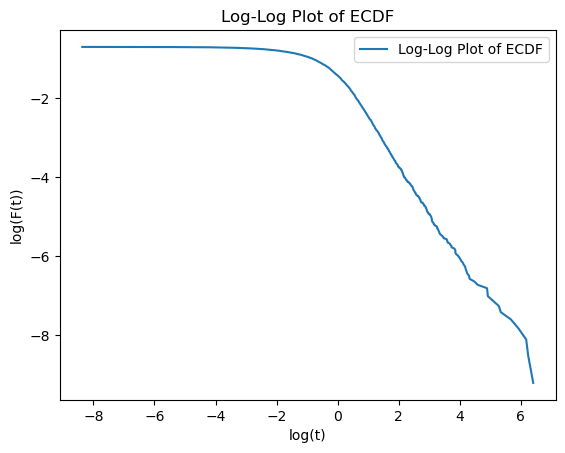

top10percentlnt: [0.87713507 0.8771878  0.87726098 0.87787234 0.87878369 0.87936691
 0.87962809 0.88054326 0.8807713  0.88147664 0.88158779 0.88242531
 0.88265722 0.88510394 0.88570724 0.88589409 0.88619884 0.8864083
 0.88669721 0.88788128 0.88820489 0.88834694 0.89084113 0.89169244
 0.8928098  0.89453559 0.89538324 0.89813873 0.89842869 0.89941704
 0.89971108 0.9004429  0.90059432 0.90133347 0.90322951 0.90332125
 0.90346643 0.90468012 0.90481284 0.90586312 0.90763895 0.90829726
 0.90864231 0.90873063 0.90880291 0.90996218 0.91134799 0.91170518
 0.91173307 0.91235097 0.91349877 0.91385904 0.91484159 0.91554443
 0.91631442 0.91714891 0.91905981 0.91972686 0.920325   0.92039148
 0.92237838 0.92396055 0.9247674  0.92506433 0.9253794  0.92563083
 0.92693236 0.927892   0.92860858 0.92903058 0.9296202  0.93179077
 0.93340348 0.93780871 0.93974593 0.94176732 0.94184599 0.94244451
 0.9427143  0.94342441 0.94553906 0.94636333 0.94731491 0.94793143
 0.9488156  0.95043274 0.95053947 0.95164132 0

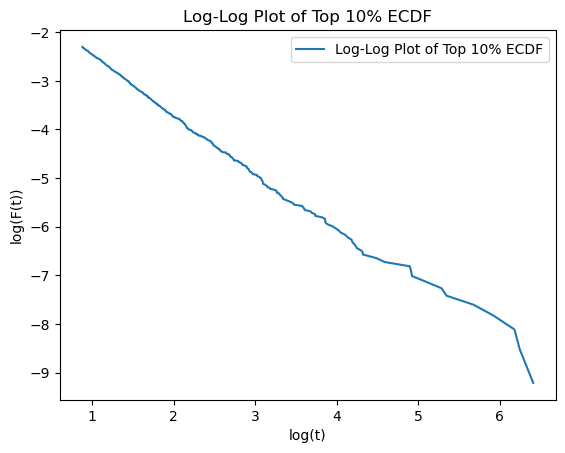

In [120]:
alpha = 1.2
beta = 0.0
gamma = 1
delta = 0

t = np.array([])
for i in range(10000):
  theta = np.random.uniform(-np.pi/2, np.pi/2)
  W = np.random.exponential(1)

  Z = genZ(alpha, beta, theta, W)
  x = S(alpha, beta, gamma, delta, 0, Z)
  t = np.append(t, x)

t = np.sort(t)
fdce = stats.ecdf(t)

lnt = np.log(t)
lnfdce = np.log(1 - fdce.cdf.probabilities)

print("lnt:", lnt)

plt.plot(lnt, lnfdce, label='Log-Log Plot of ECDF')
plt.title('Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

len_t = len(t)
top10percentlnt = lnt[int(0.9*len_t):]
top10percentlnfdce = lnfdce[int(0.9*len_t):]

print("top10percentlnt:", top10percentlnt)

plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Log-Log Plot of Top 10% ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

c_0: 0.43661518275890926
c_1: -1.2


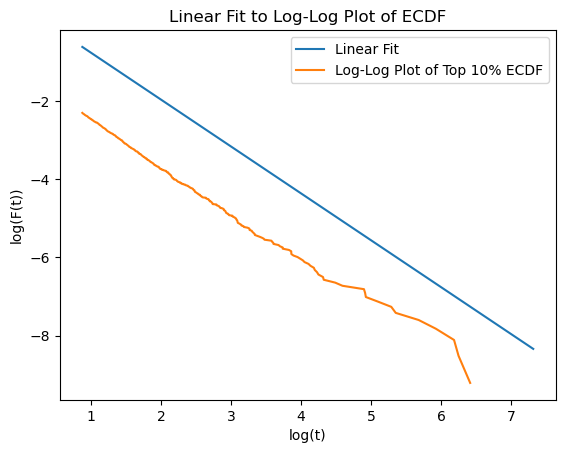

In [121]:
y = np.array([])
# c_0 = top10percentlnfdce + alpha * top10percentlnt
# c_0 = 0
c_0 = np.sin(alpha*np.pi/2) * math.gamma(alpha)/2
# c_0 = -1
c_1 = -alpha

print("c_0:", c_0)
print("c_1:", c_1)

for i in range(9000, 10000):
  x_i = top10percentlnt[i-9000]
  y_i = c_0 + c_1 * x_i
  y = np.append(y, y_i)

plt.plot(top10percentlnt, y, label='Linear Fit')
plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Linear Fit to Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

Problem 2: estymacja funkcji charakterystycznej

X ~ S_alpaha S to phi_x(t) = e^{-gamma^alpha |t|^alpha}
Stąd ln phi_x(t) = gamma^alhpa *|t|^alpha
y_k = ln |ln (est_phi_x(t_k))| = ln(gamma^alpha) + alpha ln|t_k|

x_k = ln|t_k|

c_0: 0.43661518275890926
c_1: -1.2


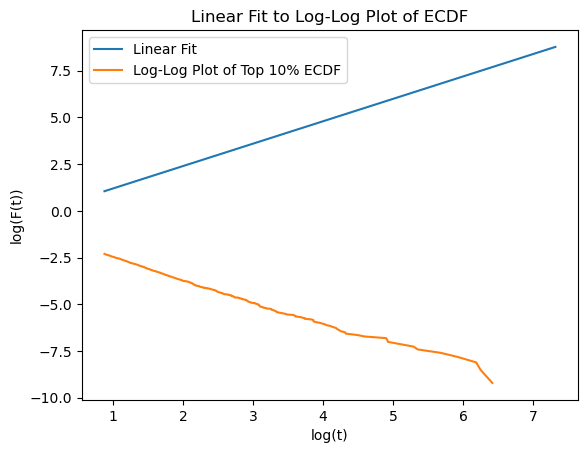

In [122]:
y = np.array([])
# c_0 = top10percentlnfdce + alpha * top10percentlnt
# c_0 = 0
c_0 = np.sin(alpha*np.pi/2) * math.gamma(alpha)/2
# c_0 = -1
c_1 = -alpha

print("c_0:", c_0)
print("c_1:", c_1)

for i in range(9000, 10000):
  x_i = top10percentlnt[i-9000]
  y_i = np.log(gamma**alpha) + alpha * x_i
  y = np.append(y, y_i)

plt.plot(top10percentlnt, y, label='Linear Fit')
plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Linear Fit to Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

znaczenie param w rozkladnie alpha stabilnym:
- alpha: stability parameter, determines the tail behavior of the distribution. For alpha < 2, the distribution has heavy tails. For alpha = 2, it reduces to a normal distribution. 

co jak jeden rapm jest wiekszy niz drugi, co jak w jednej probie beta = 1 a w drgije 0

# LISTA 3

P(eps_i = 1) = 1/2 = P(eps_i = -1)

Gamma_i = sum_k=1^i e_k

e_k ~iid~ Exp(1)

X = sum_i=1^N=inf eps_i*Gamma_i^{-1/alpha}*W_i ~ S_alpha(B=0,mi=0,sigma=(c__alhpa * (Expected|W|^alpha)^1/alpha))

for 0 <alhpa <2

In [123]:
def genEps(n):
  return np.array([np.random.choice([-1, 1]) for _ in range(n)])

def genTime(n):
  ekas = np.array([np.random.exponential(1) for _ in range(n)])
  gammas = np.array([0] * (n))
  gamma = 0
  for i in range(n):
    gamma += ekas[i]
    gammas[i] = gamma
  print(f"Generated gammas: {gammas}")
  return gammas

def genW(n):
  # return np.array([np.random.poisson(1) for _ in range(n)])
  return np.array([np.random.uniform(0, 1) for _ in range(n)])

def genSumX(n, alpha):
  epsilons = genEps(n)
  gammas = genTime(n)
  W = genW(n)
  X = np.array([0]*n)
  for i in range(n):
    print(f"i={i}, epsilons[i]={epsilons[i]}, gammas[i]={gammas[i]}, W[i]={W[i]}")
    X[i] = epsilons[i] * (gammas[i] ** (-1/alpha)) * W[i]
  return X

In [124]:
N = 100000
# TODO: POPRAWIC NIZEJ

In [125]:
# #real X for W = uniform(0,1)

# for alpha in [0.5, 1, 1.5, 1.9]:
#   expectedAbsWi = 1/(alpha+1)
#   cAlpha = np.sin(np.pi*alpha/2) * math.gamma(alpha) / np.pi
#   gamma = (1/((alpha+1) * cAlpha))**(1/alpha)
#   # gamma = 1
#   # print(f"alpha={alpha}, expectedAbsWi={expectedAbsWi}, cAlpha={cAlpha}, gamma={gamma}")  
#   estX = genSumX(N, alpha)
#   # print(f"Generated estimated X={np.mean(estX)} for alpha={alpha}")
  
#   realX = S(alpha, 0, gamma, 0, 0, genZ(alpha, 0, np.random.uniform(-np.pi/2, np.pi/2), np.random.exponential(1)))
  
#   plt.hist(estX, bins=50, density=True, alpha=0.5, label='Estimated X')
#   plt.title(f'EX alpha={alpha}')
#   plt.legend()
#   plt.show()

#   # plt.hist(estX, bins=50, density=True, alpha=0.5, label='Estimated X')
#   plt.hist(realX, bins=50, density=True, alpha=0.5, label='Real X')
#   plt.title(f'RX alpha={alpha}')
#   plt.legend()
#   plt.show()

In [126]:
# #plot re phi~(t) vs Im phi~(t) for alpha=1.5
# alpha = 1.5
# estX = genSumX(N, alpha)
# for t in np.arange(-3.0, 3.0, 0.1):
#   ePhi = estPhi(t, estX)
#   rPhi = realPhi(t, cAlpha, alpha)
#   plt.plot(t, np.real(ePhi), label='Estimated Phi')
#   plt.plot(t, np.real(rPhi), label='Real Phi')
#   plt.title('Estimated vs Real Characteristic Function')
#   plt.xlabel('t')
#   plt.ylabel('Re(Phi(t))')
#   plt.legend()
#   plt.show()

# LISTA 4

- d = 1;
Sa(b,s,u)

- d >1
Sa(gamma,mi); gamma - miara, mi \in R^d
gamma - miara na Sd = {x \in R^d: ||x||=1}

My na labach d=2
A - zb. na okręgu (S2)
gamma(A) - miara tego zb.
Gdy miara gamma ma nośnik dyskretny, {s1,...,sn} o wagach odpowiednio: {g1,...,gn} to mozna ją zapisać jak w (1):

Gamma(-)=sum_i=1^n gi*delta_si(-)

Wtedy symulujemy (jak na liscie)

X = [x1,...,xn] =(a=/=1)= sum_j=1^n gi^1/a * Zj*sj; sj - wetor, Zj - zm.los. 1D; Zj ~ iid Sa(B=1,s=1,u=0)

Potem sactter plot, Oczekujemy, skupienia dos. wokl kierunkow wyznaczanych przez {s1,...,sn}

In [127]:
def GammaMeasure(weights, points):
  gammaMeasure = 0
  for w, p in zip(weights, points):
    gammaMeasure += w * p
  return gammaMeasure

In [135]:
def genMultiDimX(weights, beta, alpha, points):
  n = len(points)
  dim = len(points[0])
  multiDimX = np.array([0.0]*dim)

  if alpha != 1:
    for j in range(n):
      theta = np.random.uniform(-np.pi/2, np.pi/2)
      W = np.random.exponential(1)
      multiDimX += weights[j]**(1/alpha)*genZ(alpha, beta, theta, W)*points[j]
  else:
    for j in range(n):
      theta = np.random.uniform(-np.pi/2, np.pi/2)
      W = np.random.exponential(1)
      multiDimX += weights[j]**(1/alpha)*(genZ(alpha, beta, theta, W) + 2/np.pi * np.log(weights[j]))*points[j]
  return multiDimX

In [ ]:
alpha = 1.5
beta = 0.0
delta = 0
gamma = 1
n = 10000

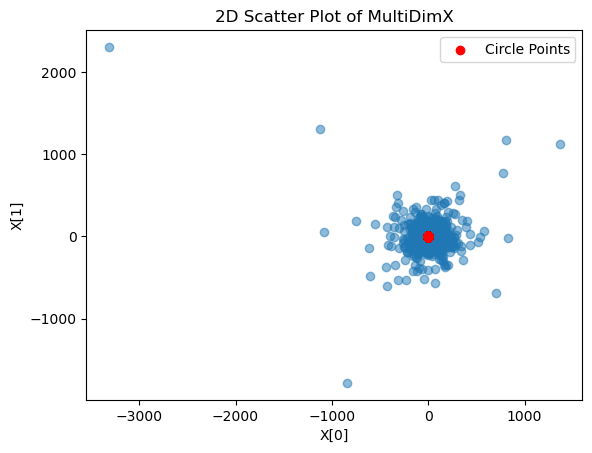

In [137]:
points2Dcircle = np.array([[np.cos(theta), np.sin(theta)] for theta in np.random.uniform(0, 2*np.pi, n)])
weights = np.array([1.0]*len(points2Dcircle))
X = np.array([[0.0, 0.0] for _ in range(n)])

for i in range(n):
  X[i] = genMultiDimX(weights, beta, alpha, points2Dcircle)

#plot points and circle on the same plot
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.scatter(points2Dcircle[:,0], points2Dcircle[:,1], color='red', label='Circle Points')
plt.legend()
plt.title('2D Scatter Plot of MultiDimX')
plt.xlabel('X[0]')
plt.ylabel('X[1]')
plt.show()

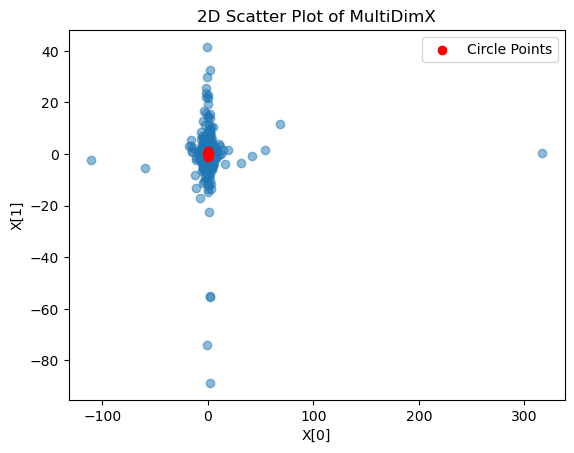

In [138]:
points2Dcircle = np.array([[0,1], [1,0], [0,-1], [-1,0]])
weights = np.array([1.0]*len(points2Dcircle))
X = np.array([[0.0, 0.0] for _ in range(n)])
for i in range(n):
  X[i] = genMultiDimX(weights, beta, alpha, points2Dcircle)

# print("X:", X)
#plot points and circle on the same plot
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.scatter(points2Dcircle[:,0], points2Dcircle[:,1], color='red', label='Circle Points')
plt.legend()
plt.title('2D Scatter Plot of MultiDimX')
plt.xlabel('X[0]')
plt.ylabel('X[1]')
plt.show()

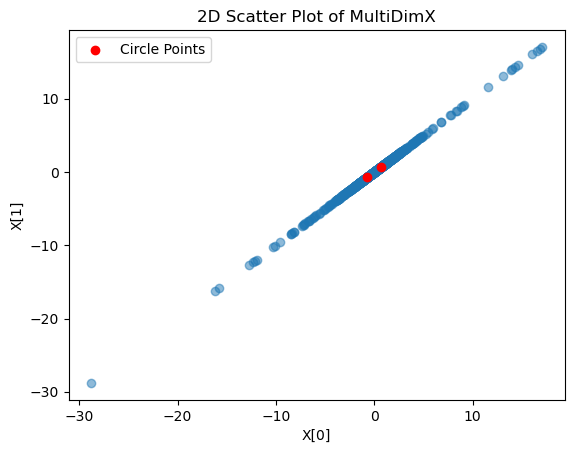

In [140]:
points2Dcircle = np.array([[np.cos(np.pi/4), np.sin(np.pi/4)], [np.cos(5/4*np.pi), np.sin(5/4*np.pi)]])
weights = np.array([1.0]*len(points2Dcircle))
X = np.array([[0.0, 0.0] for _ in range(n)])
for i in range(n):
  X[i] = genMultiDimX(weights, beta, alpha, points2Dcircle)

#plot points and circle on the same plot
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.scatter(points2Dcircle[:,0], points2Dcircle[:,1], color='red', label='Circle Points')
plt.legend()
plt.title('2D Scatter Plot of MultiDimX')
plt.xlabel('X[0]')
plt.ylabel('X[1]')
plt.show()

Histogram kątów, proba [x1(i),...,xn(i)], i = 1,...,N
arctg 2(x,y)
Filtrować wpierw obserwacje do takich ze (x1(i)^2 + x2(i)^2) >= 10, 100

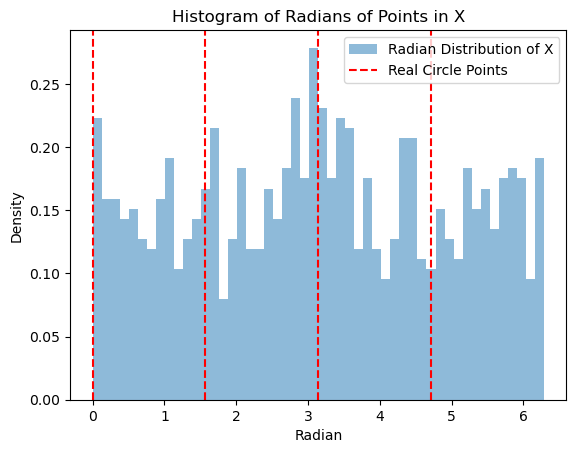

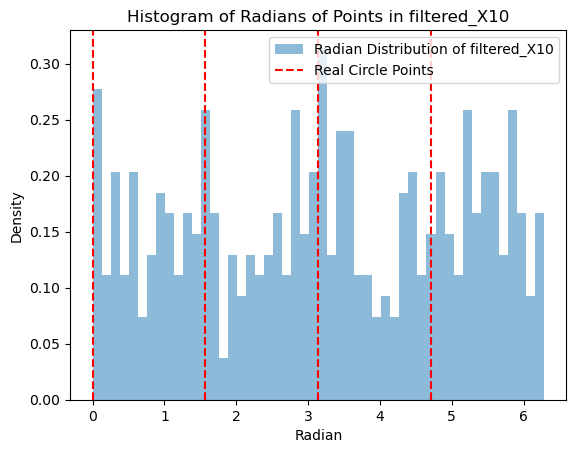

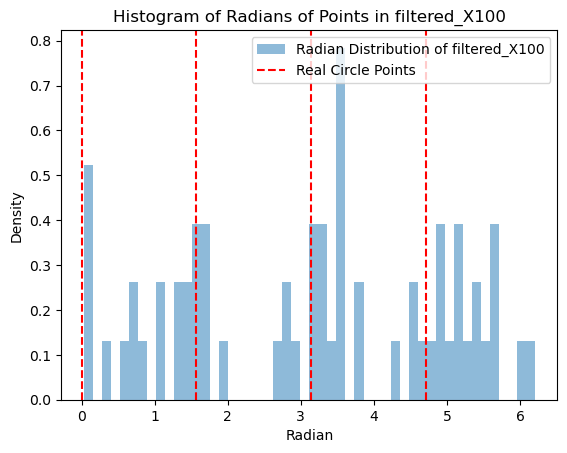

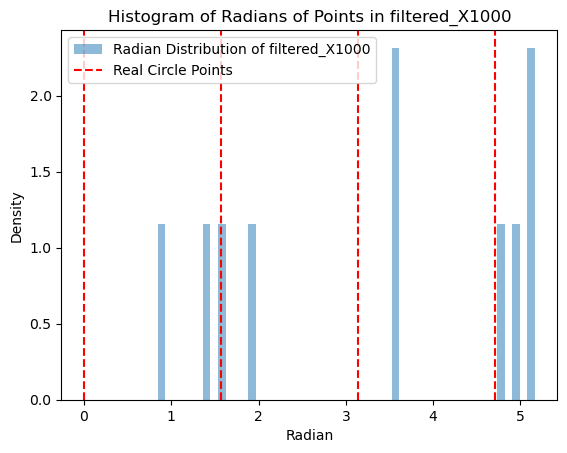

In [ ]:
phi1 = np.pi/4
phi2 = np.pi/4 + np.pi
phi3 = np.pi/4 + 2*np.pi

points2Dcircle = np.array([[0,1], [1,0], [0,-1], [-1,0]])
weights = np.array([1.0]*len(points2Dcircle))
X = np.array([[0.0, 0.0] for _ in range(n)])
for i in range(n):
  X[i] = genMultiDimX(weights, beta, alpha, points2Dcircle)

# Histogram of radians of points in X, x axis in multiples of pi, cyclic each 2*pi
radians = np.arctan2(X[:,1], X[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of X')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in X')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend()
plt.show()

#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X10 = X[np.sum(X**2, axis=1) >= 10]
# Histogram of radians of points in filtered_X10, red ones are real ones
radians = np.arctan2(filtered_X10[:,1], filtered_X10[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X10')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in filtered_X10')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X100 = X[np.sum(X**2, axis=1) >= 100]
# Histogram of radians of points in filtered_X100
radians = np.arctan2(filtered_X100[:,1], filtered_X100[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X100')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in filtered_X100')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X1000 = X[np.sum(X**2, axis=1) >= 1000]
# Histogram of radians of points in filtered_X1000
radians = np.arctan2(filtered_X1000[:,1], filtered_X1000[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X1000')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in filtered_X1000')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()


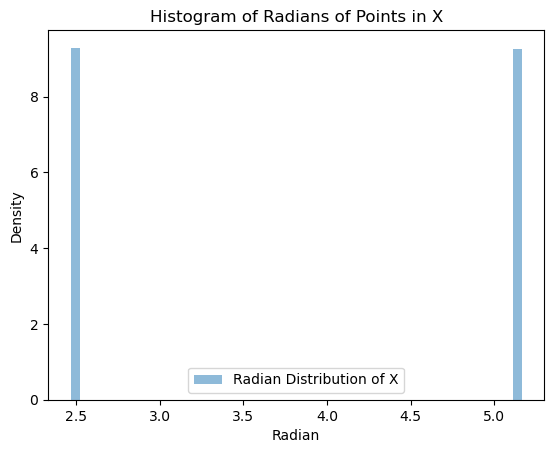

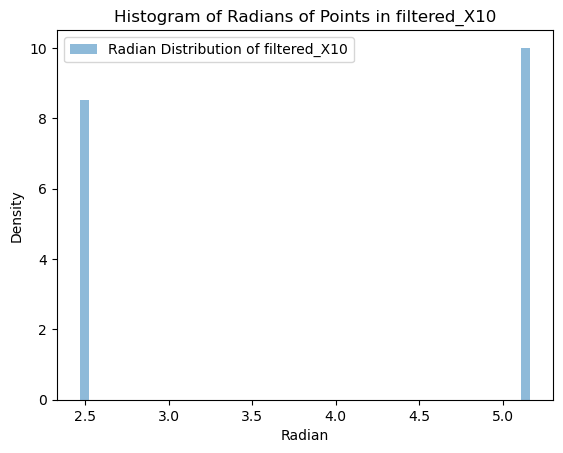

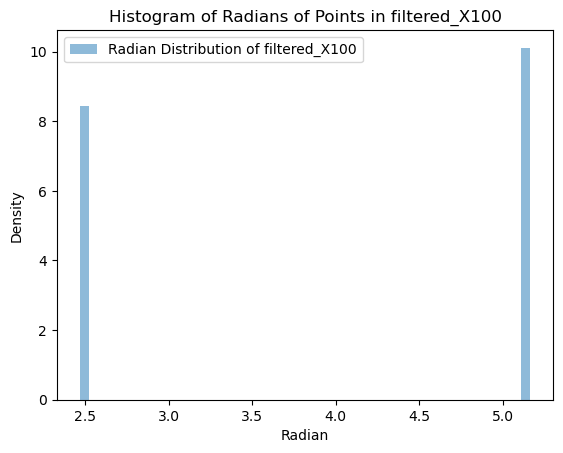

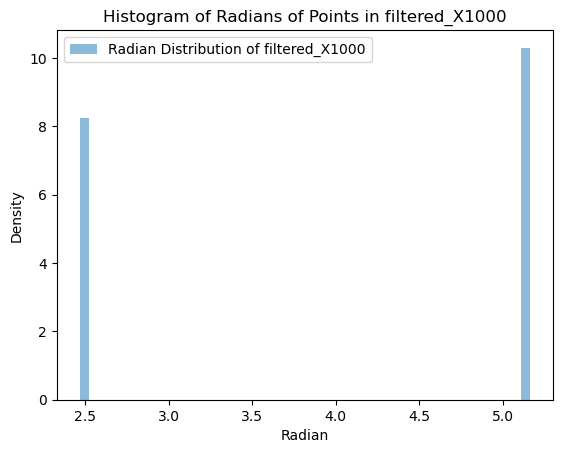

In [ ]:
phi1 = np.pi/4 
phi2 = 5/4*np.pi
points2Dcircle = np.array([[np.cos(phi1), np.sin(phi1)], [np.cos(phi2), np.sin(phi2)]])
weights = np.array([1.0]*len(points2Dcircle))
X = np.array([[0.0, 0.0] for _ in range(n)])
for i in range(n):
  X[i] = genMultiDimX(weights, beta, alpha, points2Dcircle)

# Histogram of radians of points in X, x axis in multiples of pi, cyclic each 2*pi
radians = np.arctan2(X[:,1], X[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of X')
plt.axvline(phi1, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(phi2, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in X')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend()
plt.show()

#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X10 = X[np.sum(X**2, axis=1) >= 10]
# Histogram of radians of points in filtered_X10, red ones are real ones
radians = np.arctan2(filtered_X10[:,1], filtered_X10[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X10')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in filtered_X10')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X100 = X[np.sum(X**2, axis=1) >= 100]
# Histogram of radians of points in filtered_X100
radians = np.arctan2(filtered_X100[:,1], filtered_X100[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X100')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in filtered_X100')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X1000 = X[np.sum(X**2, axis=1) >= 1000]
# Histogram of radians of points in filtered_X1000
radians = np.arctan2(filtered_X1000[:,1], filtered_X1000[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X1000')
plt.axvline(np.pi/2, color='red', linestyle='dashed', label='Real Circle Points')
plt.axvline(np.pi, color='red', linestyle='dashed')
plt.axvline(3*np.pi/2, color='red', linestyle='dashed')
plt.axvline(0, color='red', linestyle='dashed')
plt.title('Histogram of Radians of Points in filtered_X1000')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()

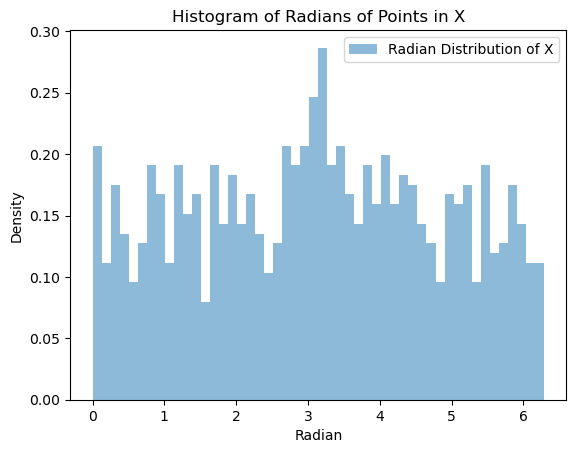

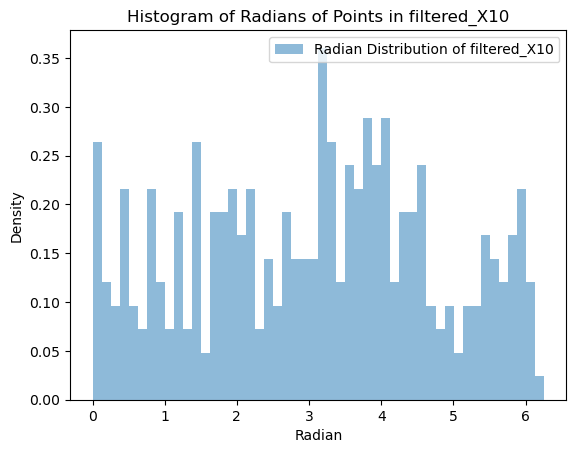

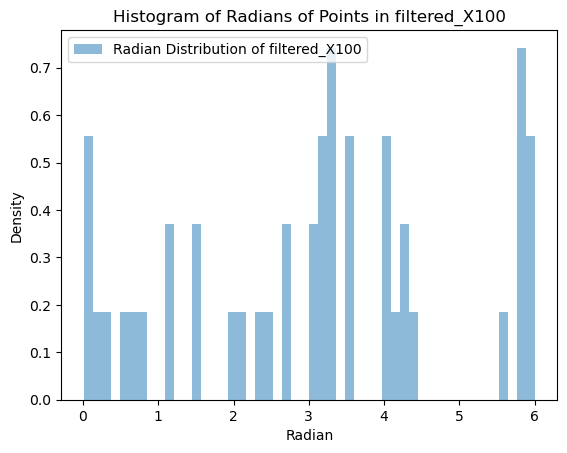

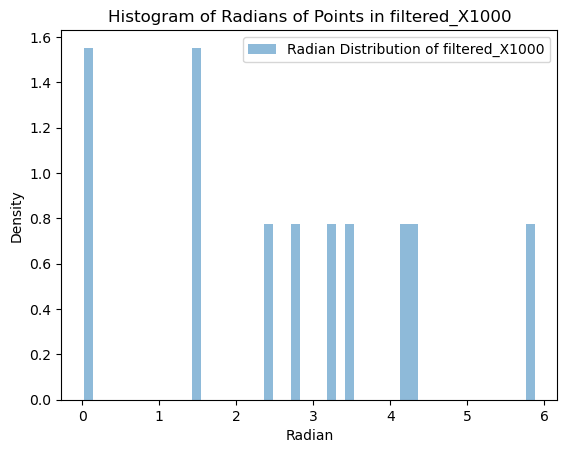

In [165]:
points2Dcircle = np.array([[np.cos(0), np.sin(0)], [np.cos(np.pi/3), np.sin(np.pi/3)], [np.cos(2.3*np.pi/2), np.sin(2.3*np.pi/2)]])
weights = np.array([1.0]*len(points2Dcircle))
X = np.array([[0.0, 0.0] for _ in range(n)])
for i in range(n):
  X[i] = genMultiDimX(weights, beta, alpha, points2Dcircle)

# Histogram of radians of points in X, x axis in multiples of pi, cyclic each 2*pi
radians = np.arctan2(X[:,1], X[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of X')
plt.title('Histogram of Radians of Points in X')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend()
plt.show()

#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X10 = X[np.sum(X**2, axis=1) >= 10]
# Histogram of radians of points in filtered_X10
radians = np.arctan2(filtered_X10[:,1], filtered_X10[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X10')
plt.title('Histogram of Radians of Points in filtered_X10')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X100 = X[np.sum(X**2, axis=1) >= 100]
# Histogram of radians of points in filtered_X100
radians = np.arctan2(filtered_X100[:,1], filtered_X100[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X100')
plt.title('Histogram of Radians of Points in filtered_X100')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X1000 = X[np.sum(X**2, axis=1) >= 1000]
# Histogram of radians of points in filtered_X1000
radians = np.arctan2(filtered_X1000[:,1], filtered_X1000[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X1000')
plt.title('Histogram of Radians of Points in filtered_X1000')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()


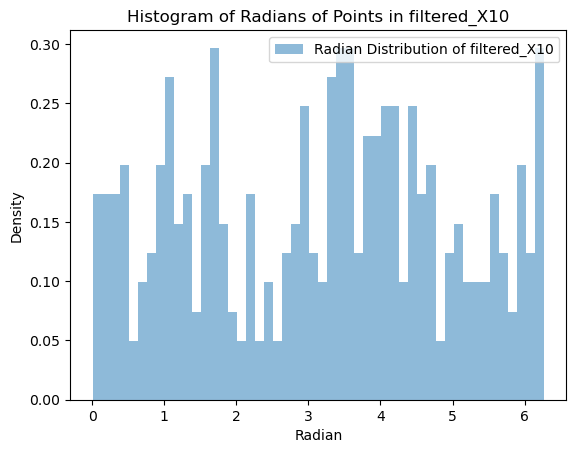

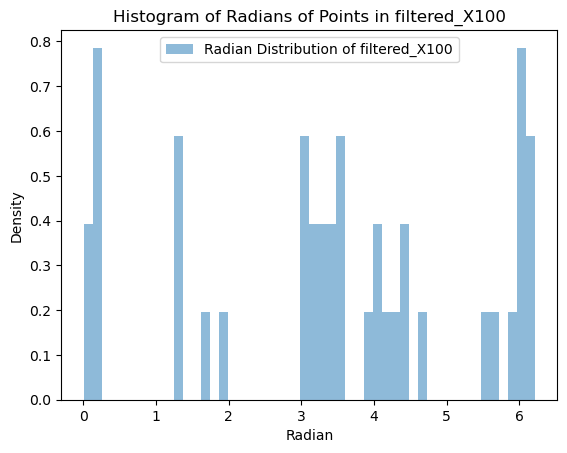

In [162]:
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X10 = X[np.sum(X**2, axis=1) >= 10]
# Histogram of radians of points in filtered_X10
radians = np.arctan2(filtered_X10[:,1], filtered_X10[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X10')
plt.title('Histogram of Radians of Points in filtered_X10')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()
#Filter: point counts if (x1(i)^2 + x2(i)^2) >= 10, 100
filtered_X100 = X[np.sum(X**2, axis=1) >= 100]
# Histogram of radians of points in filtered_X100
radians = np.arctan2(filtered_X100[:,1], filtered_X100[:,0])%2*np.pi
plt.hist(radians, bins=50, density=True, alpha=0.5, label='Radian Distribution of filtered_X100')
plt.title('Histogram of Radians of Points in filtered_X100')
plt.xlabel('Radian')
plt.ylabel('Density')
plt.legend() 
plt.show()